having cleaned up the data, let's now look at it. 

We will be using the usual suspects, numpy, pandas, matplotlib, 
and also seaborn, a visualisation library that is built on top of the aformentioned ones. 

In [2]:
%matplotlib inline

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

In [3]:
df = pd.read_pickle('smfish.pkl')

In [4]:
#inspecting

df.head()

,FILE,CELL,AREA_cell,AREA_nuc,N_total,N_thres_Total,N_thres_Nuc,mrna,condition
0,WTGLU_01_CY3_outline.txt,Cell_CP_1,1256.0,223.0,3,3,2,DOA1,GLU
1,WTGLU_01_CY3_outline.txt,Cell_CP_2,1522.5,353.0,4,4,0,DOA1,GLU
2,WTGLU_01_CY3_outline.txt,Cell_CP_3,1778.0,431.0,3,3,1,DOA1,GLU
3,WTGLU_01_CY3_outline.txt,Cell_CP_4,472.0,214.0,2,2,1,DOA1,GLU
4,WTGLU_01_CY3_outline.txt,Cell_CP_5,1016.0,213.5,2,2,1,DOA1,GLU


## correlation of DOA1 and GAL1

In the syllabus, you saw scatterplots with histograms in the margins.
<br>
In seaborn, this type of plot is implemented as a jointplot:
<br>
Let's make one for the RAFF to GAL condition

In [5]:
# find unique entries in the condition column (i.e. the conditions)
df['condition'].unique()

array(['GLU', 'GLUGAL', 'RAFF', 'RAFFGAL'], dtype=object)

In [6]:
# extract the condition of interest:
data = df[df['condition']=='RAFFGAL']

# use pivot table to reformat the data:
data = data.pivot_table(index=data.index, columns='mrna', values='N_thres_Total')
data.head()

mrna,DOA1,GAL1
6024,0.0,24.0
6025,3.0,33.0
6026,1.0,55.0
6027,3.0,32.0
6028,1.0,17.0


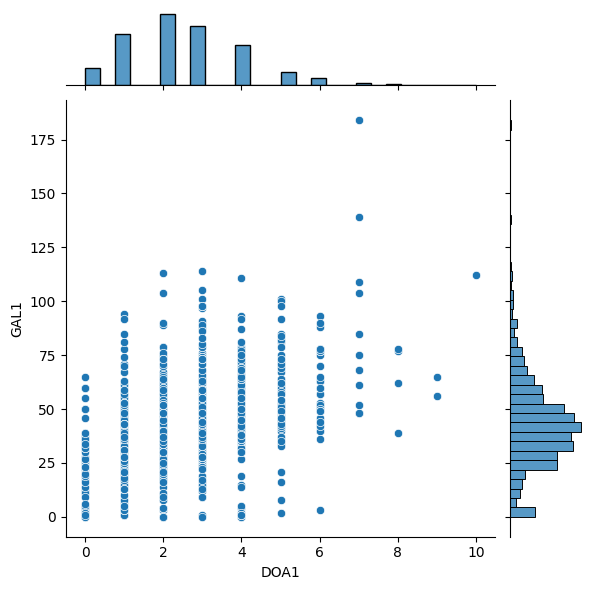

In [ ]:
sns.jointplot(data=data, x='DOA1', y='GAL1')


### your turn:

repeat with the other conditions and compare.

What behaviour is expected?

you can change the scale of the plots by feeding xlim, ylim arguments:

`sns.jointplot(data=data, x='DOA1', y='GAL1', ylim=(-10,200), xlim=(0,20))`

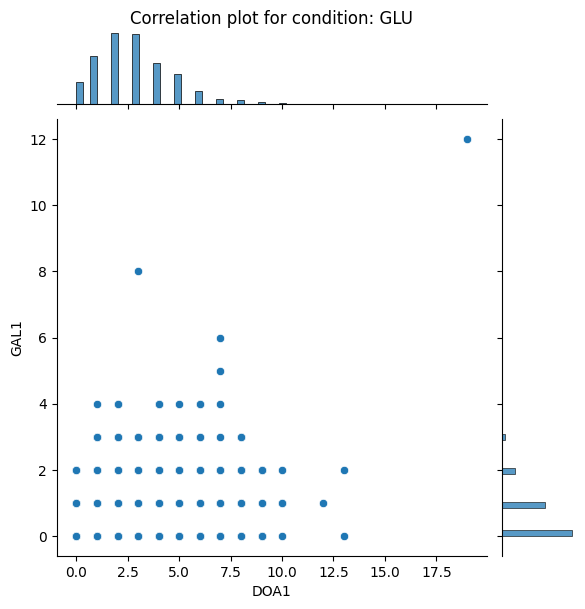

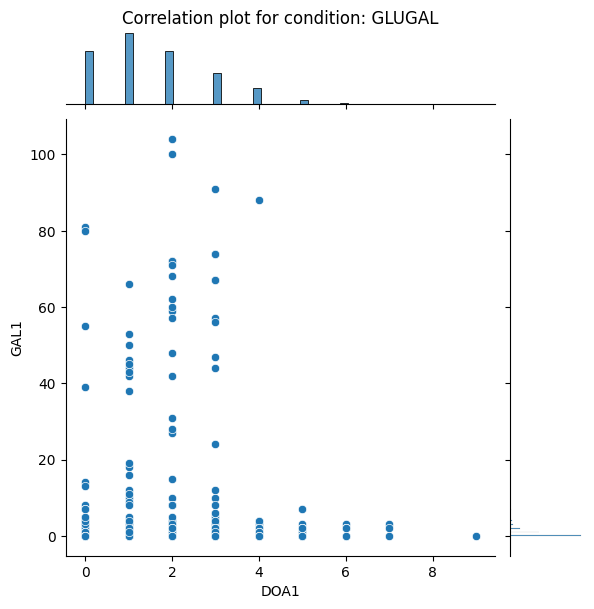

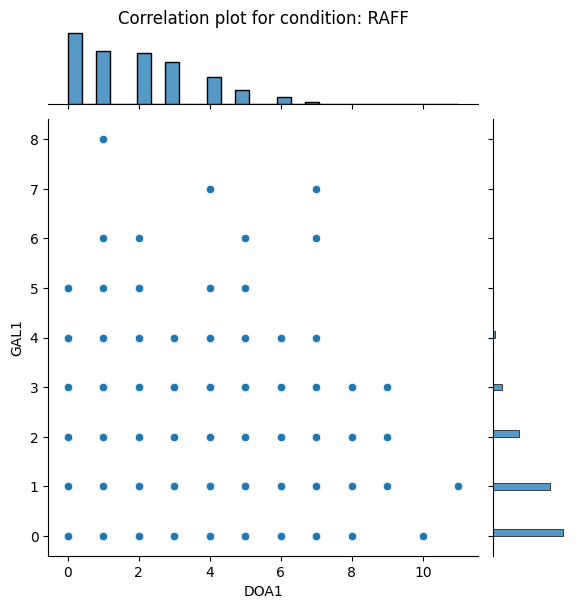

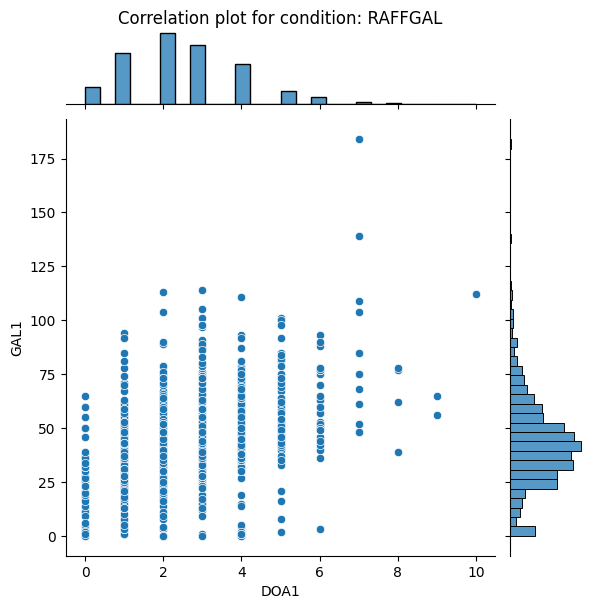

In [19]:
# your code here
for condition in df['condition'].unique():
    data = df[df['condition']==condition]

    # use pivot table to reformat the data:
    data = data.pivot_table(index=data.index, columns='mrna', values='N_thres_Total')
    
    sns.jointplot(data=data, x='DOA1', y='GAL1')
    plt.title(f"Correlation plot for condition: {condition}",y=1.2)




In [9]:
# your code here



In [10]:
# your code here



You can also visualise differences in conditions with a boxplot:

<Axes: xlabel='condition', ylabel='N_thres_Total'>

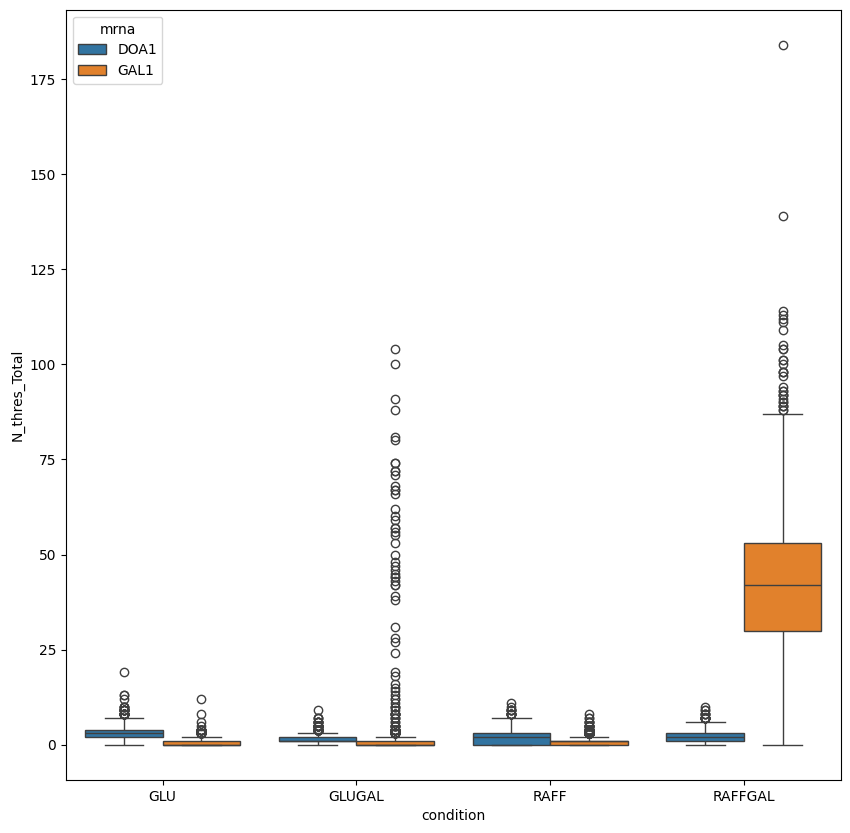

In [ ]:
fig, ax= plt.subplots(figsize=(10,10,))

sns.boxplot(x='condition', y='N_thres_Total', data=df, hue='mrna')
plt.ylabel("mRNAs/cell")

Alternatively, use a violinplot.

Seaborn implements violinplots in different ways.
Here, we use the 'violin' option in sns.catplot, which is short for categorical plot:

Text(41.84804079861111, 0.5, 'mRNAs/cell')

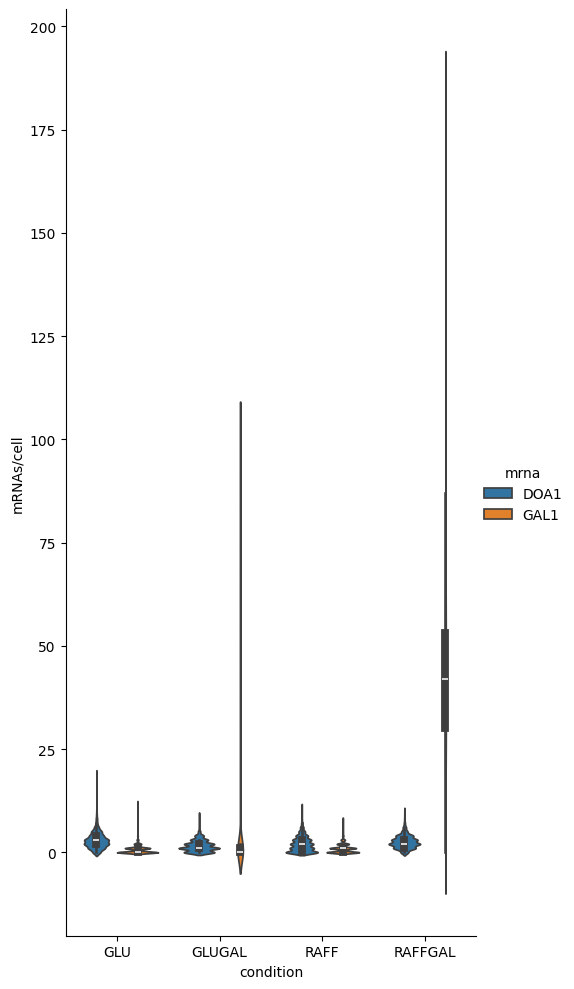

In [30]:
sns.catplot(
    x='condition', 
    y='N_thres_Total', 
    data=df, 
    hue='mrna', 
    kind='violin', 
    height=10, 
    aspect=0.5
)
plt.ylabel("mRNAs/cell")

Seaborn features many other kinds of plots to visualise data. One of the more important and useful ones is the dogplot, named with a nod to the catplot. The implementation is straightforward:

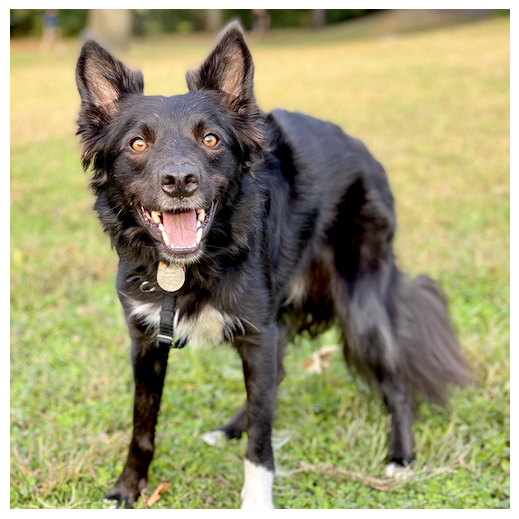

In [49]:
sns.dogplot()

### your turn:



What do you observe?


How do the differences in constitutively expressed and inducible mRNAs manifest themselves?


What effect does prior exposure to glucose have on the transition to galactose growth? 


The transcript counts reflect how many cells are commiting to galactose growth. How do the data displayed here tie in with the remaining datasets?


Which transition is noisier?


Why?